# Time series analysis of Ukrainian air raid alerts

Data: Ukraine's official air raid alert records, 15 March 2022 - today (source: [alerts.in.ua](https://alerts.in.ua), mirrored on [GitHub](https://github.com/Vadimkin/ukrainian-air-raid-sirens-dataset)).

## Questions this analysis answers

1. **Has alert activity changed since 2022?**
2. **Is there a weekly/hourly pattern — are some days more dangerous than others?**
3. **Which regions of Ukraine have been hit hardest?**
4. **Were there unusually severe days, and do they match real documented attacks?**
5. **Can future alert activity be forecast with any reliability?**

**Method, in one line:** the data is cleaned (duplicate entries removed) and measured as **the number of Ukraine's 25 regions placed under alert each day** — a simple, reliable gauge of how widespread the danger was on any given day.

In [30]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import ruptures as rpt
import json, glob
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

import contextlib, os
@contextlib.contextmanager
def quiet():
    with open(os.devnull, 'w') as devnull, contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            yield

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.titlesize'] = 12

from alerts_loader import load_official_alerts
LOCAL_TZ = 'Europe/Kyiv'

In [31]:
df = load_official_alerts(local_tz=LOCAL_TZ)
df['date'] = df['started_at_local'].dt.normalize()
print(f"{len(df):,} clean alert events | {df['started_at'].min().date()} -> {df['started_at'].max().date()}")

dedup: dropped 113,845/271,160 exact duplicate rows (42.0%)
flagged 686 long-duration alerts (>24h) -- kept as-is, mostly frontline raions under continuous threat
flagged 2 likely data-error rows (>30d) -- duration excluded via duration_min_clean, event itself kept
157,315 clean alert events | 2022-03-15 -> 2026-06-20


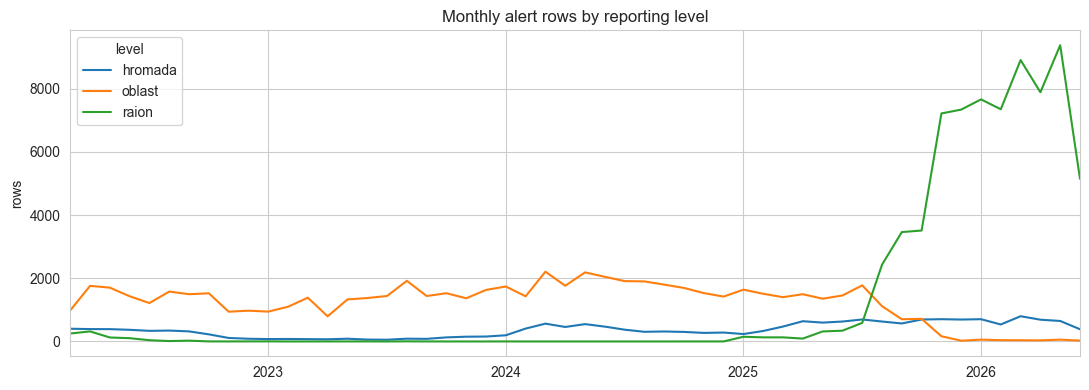

In [32]:
monthly_by_level = (df.assign(month=df['date'].dt.to_period('M'))
                       .pivot_table(index='month', columns='level', values='oblast', aggfunc='count')
                       .fillna(0))
monthly_by_level.index = monthly_by_level.index.to_timestamp()
fig, ax = plt.subplots(figsize=(11, 4))
monthly_by_level.plot(ax=ax)
ax.set_title('Monthly alert rows by reporting level')
ax.set_ylabel('rows'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

*The spike is raion alerts isn't a real explosion in attacks.*


It's the alert system itself changing how granular its logging is — switching from "flag the whole oblast" to "flag the specific district within it." A single attack that previously generated one oblast-level row now generates many raion-level rows

In [33]:
daily = df.groupby('date')['oblast'].nunique().rename('oblasts_under_alert')
daily.index = daily.index.tz_localize(None)
daily = daily.asfreq('D')
print(f'series length: {len(daily)} days ({daily.index.min().date()} -> {daily.index.max().date()})')
print(f'missing calendar days: {daily.isna().sum()}')

series length: 1559 days (2022-03-15 -> 2026-06-20)
missing calendar days: 0


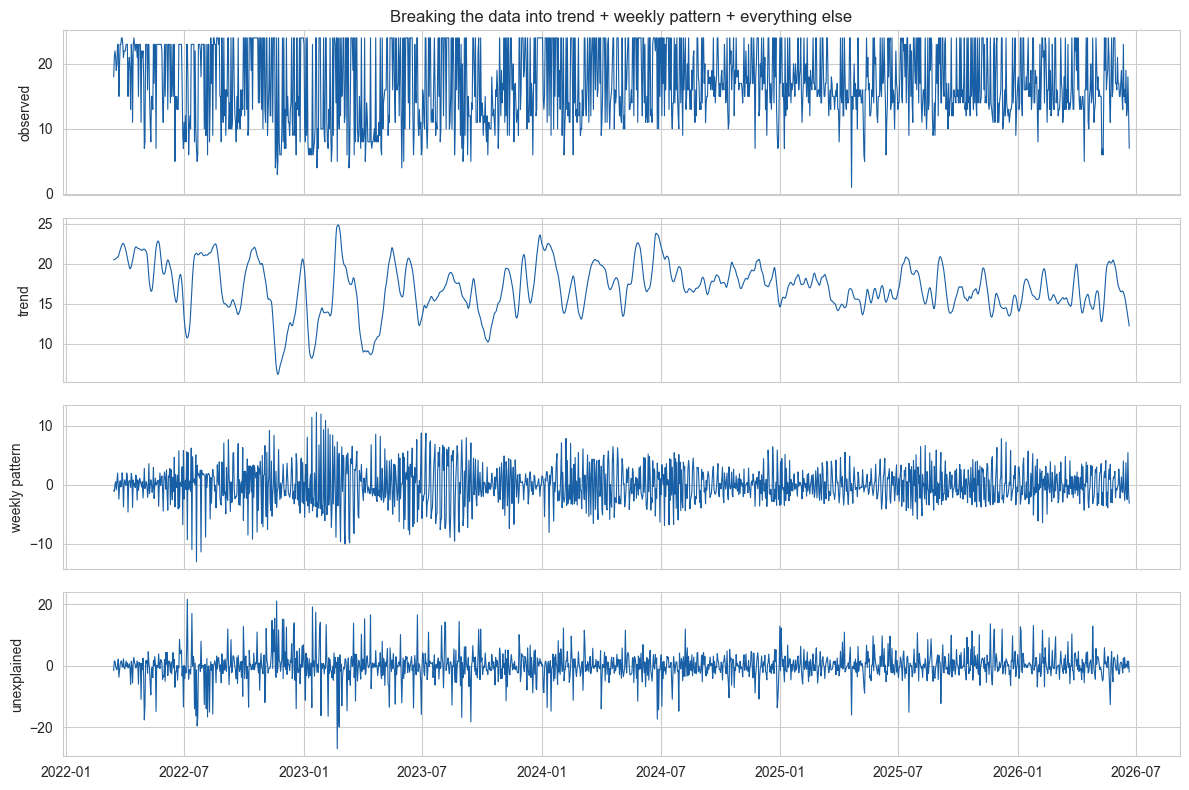

In [34]:
stl = STL(daily, period=7, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, comp, name in zip(axes, [daily, stl.trend, stl.seasonal, stl.resid],
                           ['observed', 'trend', 'weekly pattern', 'unexplained']):
    ax.plot(comp.index, comp.values, lw=0.8, color='#185FA5')
    ax.set_ylabel(name, fontsize=10)
axes[0].set_title('Breaking the data into trend + weekly pattern + everything else')
plt.tight_layout(); plt.show()

## 1. Has alert activity changed since 2022?

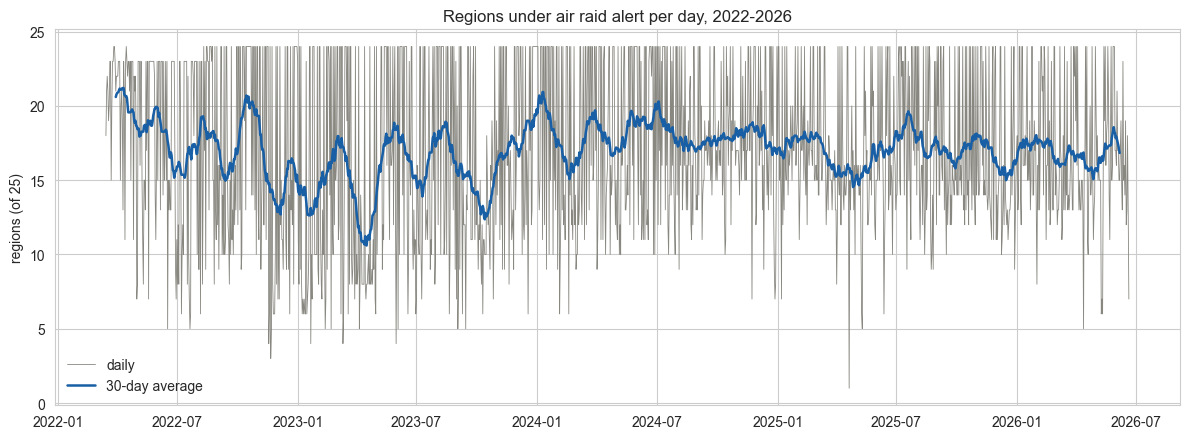

In [35]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.index, daily.values, lw=0.6, color='#888780', label='daily')
ax.plot(daily.index, daily.rolling(30, center=True).mean(), lw=1.8, color='#185FA5', label='30-day average')
ax.set_title('Regions under air raid alert per day, 2022-2026')
ax.set_ylabel('regions (of 25)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

- Highest and most widespread in the **opening months of the 2022 invasion** — March-May 2022 averaged 21 of 25 regions under alert (vs. ~17 typical), with 22+ regions hit at once on most days that quarter
- The war's single most volatile stretch was **November 2022 - June 2023**: it contains both the calmest day on record (22 November 2022) and the highest point of the entire war (20-25 February 2023, when nearly all 25 regions were under alert at once) — the latter coinciding with President Biden's surprise visit to Kyiv and the one-year invasion anniversary
- Elevated and steadier since late 2023 — busier on average than that volatile stretch, but in a narrower, more consistent band
- On an average day, **about 17 of Ukraine's 25 regions** are under alert

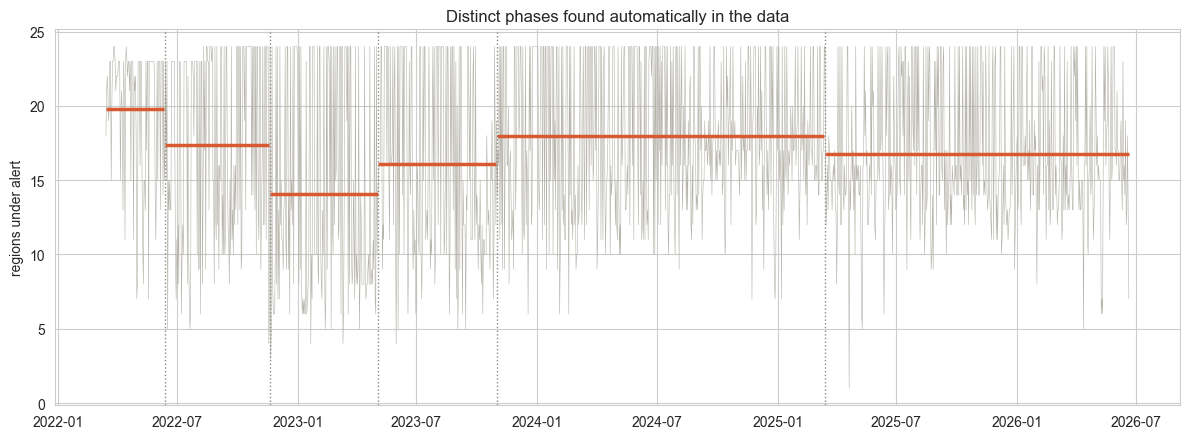

2022-03-15 -> 2022-06-12  avg = 19.8
2022-06-13 -> 2022-11-19  avg = 17.4
2022-11-20 -> 2023-05-03  avg = 14.1
2023-05-04 -> 2023-10-30  avg = 16.1
2023-10-31 -> 2025-03-13  avg = 18.0
2025-03-14 -> 2026-06-20  avg = 16.7


In [36]:
signal = daily.values.astype(float)
algo = rpt.Binseg(model='l2', min_size=30, jump=5).fit(signal)
breaks = [b for b in algo.predict(n_bkps=5) if b < len(signal)]
bounds = [0] + breaks + [len(signal)]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.index, daily.values, lw=0.4, color='#B4B2A9')
for i in range(len(bounds)-1):
    seg_idx = daily.index[bounds[i]:bounds[i+1]]
    seg_mean = signal[bounds[i]:bounds[i+1]].mean()
    ax.hlines(seg_mean, seg_idx[0], seg_idx[-1], color='#D85A30', lw=2.5)
for b in breaks:
    ax.axvline(daily.index[b], color='#888780', ls=':', lw=1)
ax.set_title('Distinct phases found automatically in the data')
ax.set_ylabel('regions under alert')
plt.tight_layout(); plt.show()

for i in range(len(bounds)-1):
    print(daily.index[bounds[i]].date(), '->', daily.index[bounds[i+1]-1].date(),
          ' avg =', round(signal[bounds[i]:bounds[i+1]].mean(),1))

The data splits itself into **6 distinct phases**, found automatically, with no dates given to the method in advance:

| Phase | Average | What it lines up with |
|---|---|---|
| Mar-Jun 2022 | 19.8 | Opening invasion shock |
| Jun-Nov 2022 | 17.4 | Shift to grinding fight in the east |
| Nov 2022-May 2023 | 14.1 | The war's quietest, most erratic stretch |
| May-Oct 2023 | 16.1 | Build-up to Ukraine's 2023 counteroffensive |
| Oct 2023-Mar 2025 | 18.0 | Longest, most elevated phase — sustained drone/missile campaigns |
| Mar 2025-now | 16.7 | Current period |

This is an independent check on the "has it changed" question — it finds the same story as the chart above, without being told where to look.

## 2. Pattern by Phase

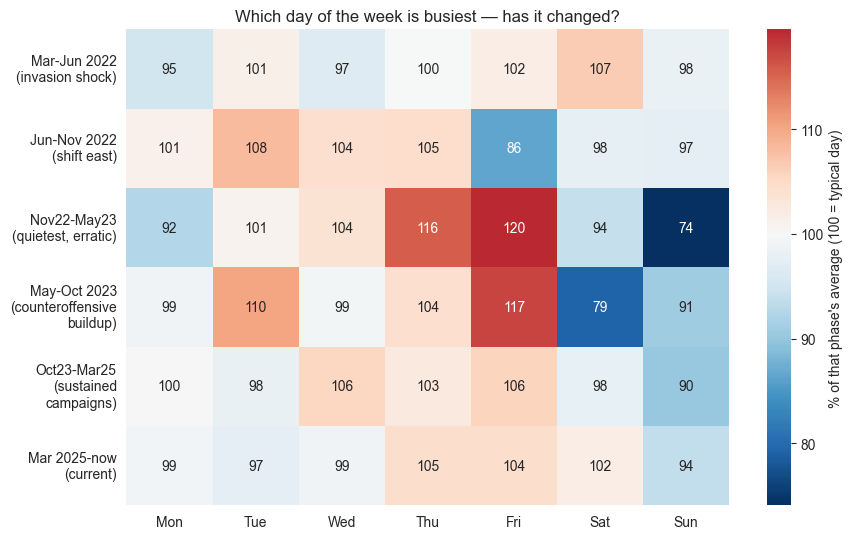

In [37]:
phase_bounds = ['2022-03-15','2022-06-13','2022-11-20','2023-05-04','2023-10-31','2025-03-14','2026-06-21']
phase_labels = ['Mar-Jun 2022\n(invasion shock)','Jun-Nov 2022\n(shift east)','Nov22-May23\n(quietest, erratic)',
                 'May-Oct 2023\n(counteroffensive\nbuildup)','Oct23-Mar25\n(sustained\ncampaigns)','Mar 2025-now\n(current)']
def assign_phase(dates):
    return pd.cut(dates, bins=pd.to_datetime(phase_bounds), labels=phase_labels, right=False)

daily_df = daily.to_frame('val')
daily_df['phase'] = assign_phase(daily_df.index)
daily_df['dow'] = daily_df.index.dayofweek
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekly_by_phase = daily_df.groupby(['phase','dow'], observed=True)['val'].mean().unstack()
weekly_by_phase.columns = dow_labels
weekly_norm = weekly_by_phase.div(weekly_by_phase.mean(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(weekly_norm, cmap='RdBu_r', center=100, annot=True, fmt='.0f',
            cbar_kws={'label': "% of that phase's average (100 = typical day)"}, ax=ax)
ax.set_title('Which day of the week is busiest — has it changed?')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

Alerts tend to concentrate in the middle of the week **towards Friday**, and their frequency falls on weekends.

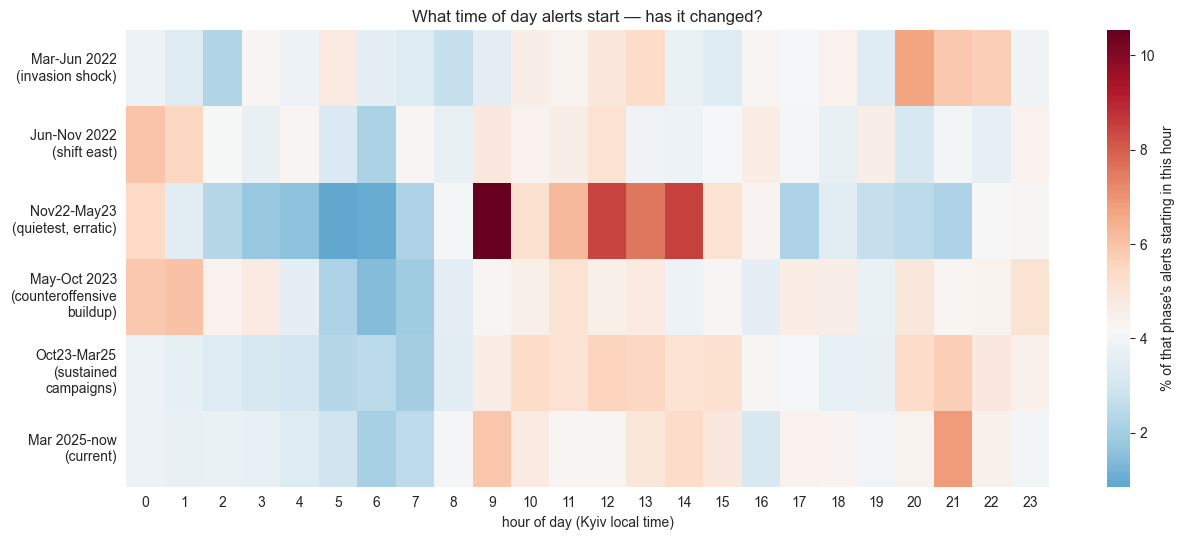

In [38]:
oblast_events = df[df['level']=='oblast'].copy()
oblast_events['phase'] = assign_phase(oblast_events['date'].dt.tz_localize(None))
oblast_events['hour'] = oblast_events['started_at_local'].dt.hour
hourly_by_phase = oblast_events.groupby(['phase','hour'], observed=True).size().unstack(fill_value=0)
hourly_norm = hourly_by_phase.div(hourly_by_phase.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(hourly_norm, cmap='RdBu_r', center=100/24,
            cbar_kws={'label': "% of that phase's alerts starting in this hour"}, ax=ax)
ax.set_title('What time of day alerts start — has it changed?')
ax.set_xlabel('hour of day (Kyiv local time)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

Alerts often start in between 9AM and 3PM with another wave hitting after 8PM.

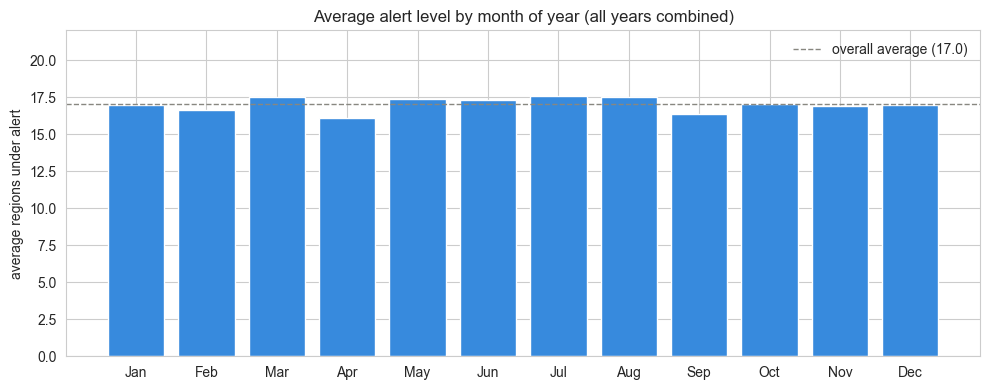

In [39]:
monthly = daily.groupby(daily.index.month).mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(months, monthly.values, color='#378ADD')
ax.axhline(daily.mean(), color='#888780', ls='--', lw=1, label=f'overall average ({daily.mean():.1f})')
ax.set_ylabel('average regions under alert')
ax.set_title('Average alert level by month of year (all years combined)')
ax.legend(frameon=False); ax.set_ylim(0, 22)
plt.tight_layout(); plt.show()

Russia's most severe attacks on Ukraine's power grid have historically come in winter — so a winter spike here would be the expected pattern. There **isn't one**: every month averages within about 1.5 regions of the yearly mean. The winter energy campaigns are real, but they concentrate on a small number of specific targets rather than triggering broad nationwide alerts — so they don't show up in *how many regions* are alerted, only in *how damaging* the strikes are.

A real but modest **weekly rhythm** exists — more visible during quieter periods of the war, flatter during the most intense stretches

In [40]:
def report(name, series):
    a = adfuller(series); k = kpss(series, regression='c', nlags='auto')
    print(f'{name:10s}  trend-test stat={a[0]:7.2f} p={a[1]:.4f}   |   stability-test stat={k[0]:.3f} p={k[1]:.4f}')
report('raw', daily)
report('day-to-day change', daily.diff().dropna())

raw         trend-test stat= -10.26 p=0.0000   |   stability-test stat=0.223 p=0.1000
day-to-day change  trend-test stat= -14.15 p=0.0000   |   stability-test stat=0.500 p=0.0417


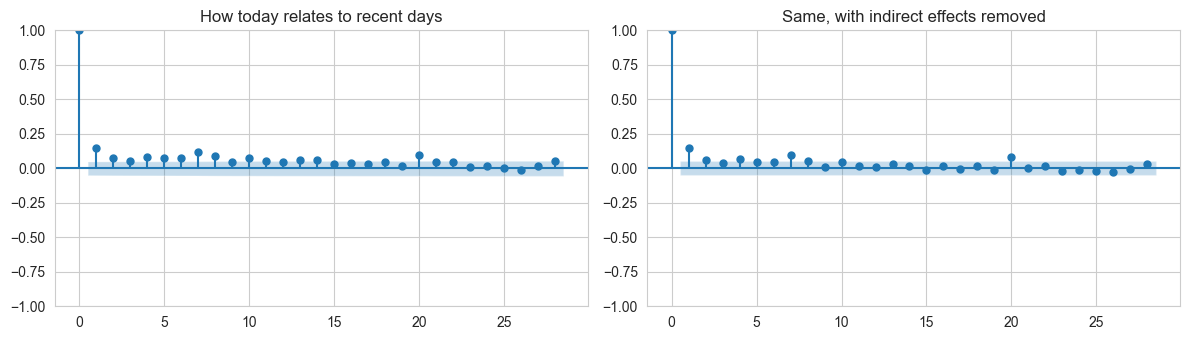

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(daily, lags=28, ax=axes[0]); plot_pacf(daily, lags=28, ax=axes[1])
axes[0].set_title('How today relates to recent days')
axes[1].set_title('Same, with indirect effects removed')
plt.tight_layout(); plt.show()

Alert activity has **very little carry-over** from one day to the next — a quiet day only weakly predicts a quiet tomorrow

## 3. Which regions have been hit hardest?

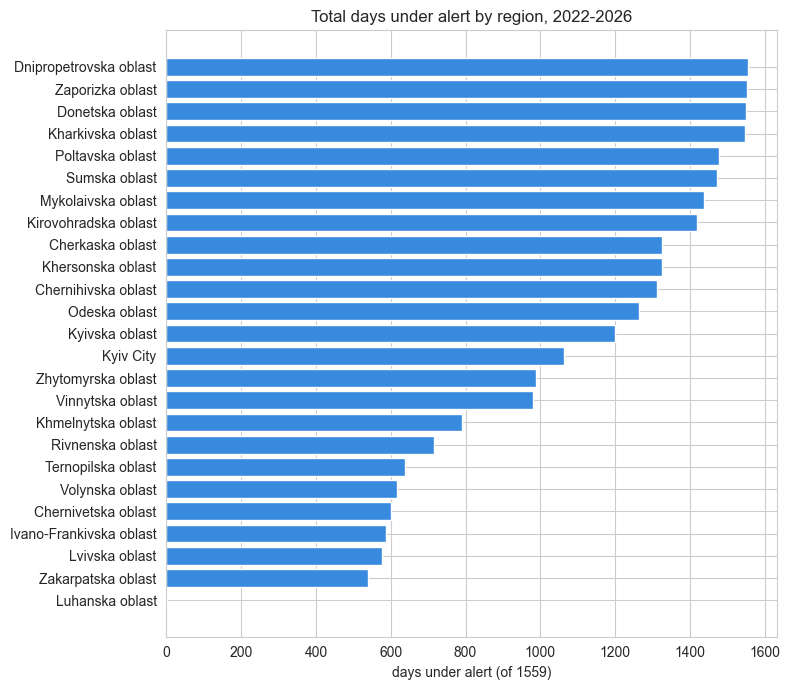

In [42]:
presence = (df.drop_duplicates(['oblast', 'date'])
              .assign(flag=1)
              .pivot(index='date', columns='oblast', values='flag')
              .fillna(0))
totals = presence.sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(totals.index, totals.values, color='#378ADD')
ax.set_xlabel('days under alert (of %d)' % len(presence))
ax.set_title('Total days under alert by region, 2022-2026')
plt.tight_layout(); plt.show()

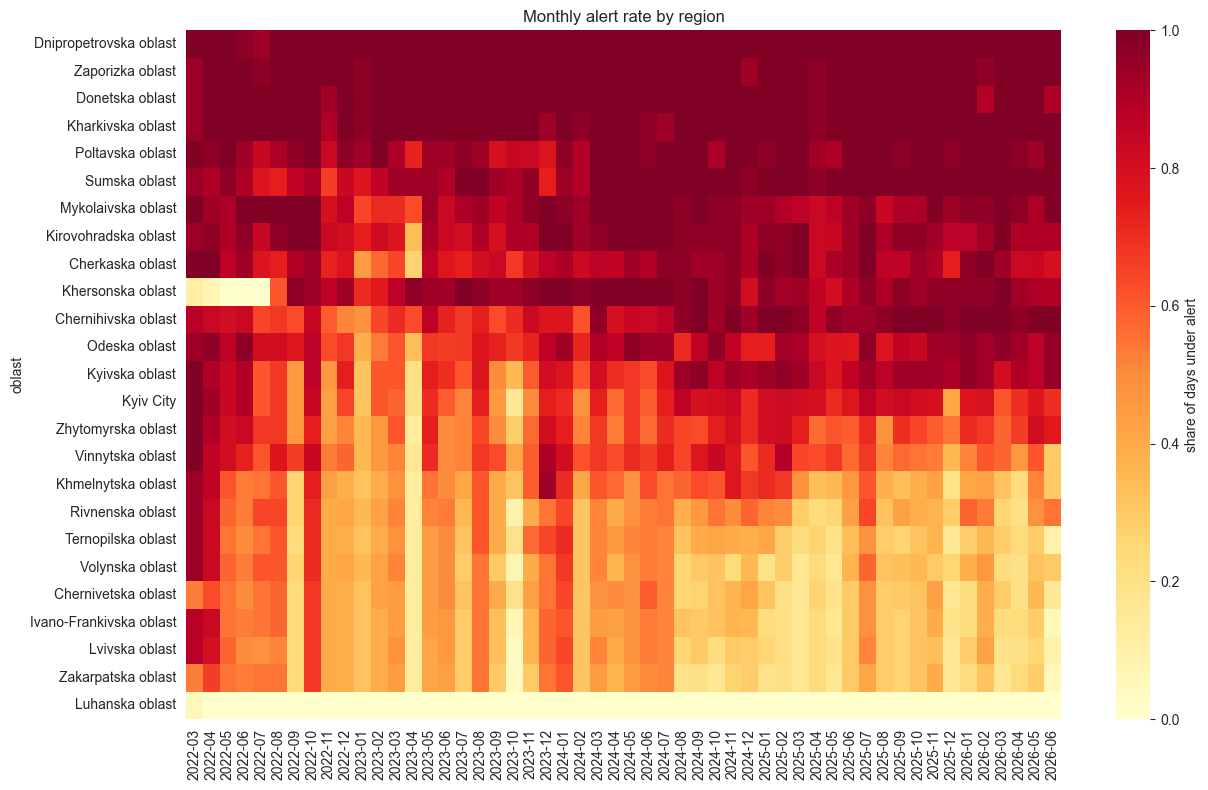

In [43]:
monthly_rate = (presence.groupby(presence.index.to_period('M')).mean()
                  .reindex(columns=totals.index[::-1]))
monthly_rate.index = monthly_rate.index.astype(str)
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(monthly_rate.T, cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'label': 'share of days under alert'}, ax=ax)
ax.set_title('Monthly alert rate by region'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

Same numbers, on an actual map — the front-line pattern is immediate:

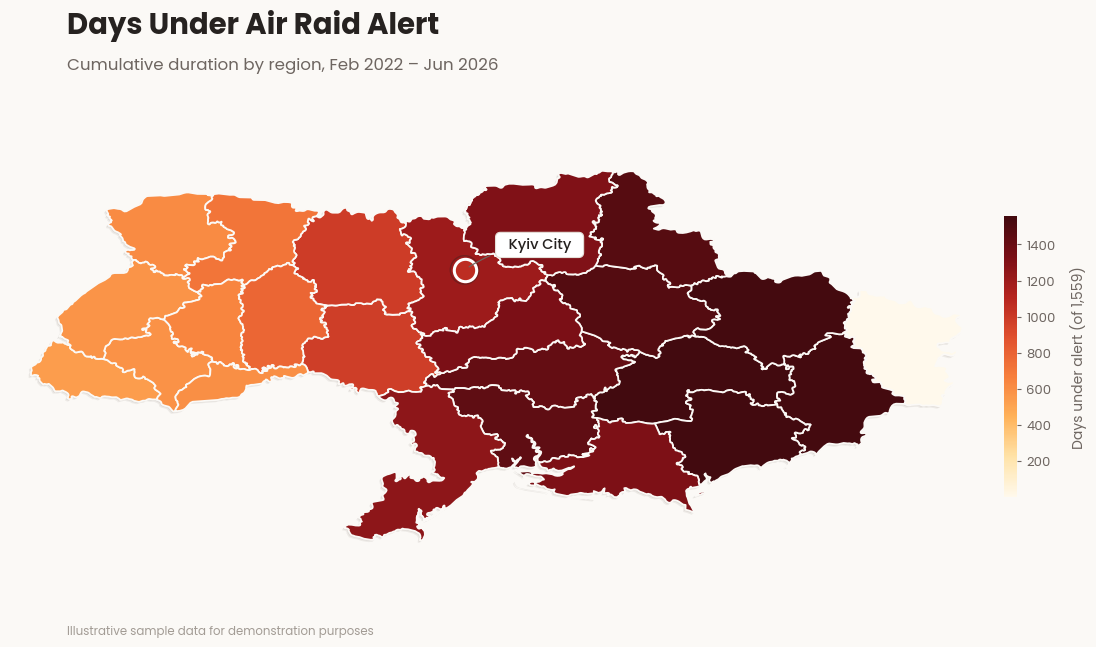

In [44]:
import json, requests
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.patches import Polygon, FancyBboxPatch
from matplotlib.collections import PatchCollection


geo_name_map = {
    'UA_05_Vinnytska.geojson':'Vinnytska oblast','UA_07_Volynska.geojson':'Volynska oblast',
    'UA_09_Luhanska.geojson':'Luhanska oblast','UA_12_Dnipropetrovska.geojson':'Dnipropetrovska oblast',
    'UA_14_Donetska.geojson':'Donetska oblast','UA_18_Zhytomyrska.geojson':'Zhytomyrska oblast',
    'UA_21_Zakarpatska.geojson':'Zakarpatska oblast','UA_23_Zaporizka.geojson':'Zaporizka oblast',
    'UA_26_Ivano_Frankivska.geojson':'Ivano-Frankivska oblast','UA_32_Kyivska.geojson':'Kyivska oblast',
    'UA_35_Kirovohradska.geojson':'Kirovohradska oblast','UA_46_Lvivska.geojson':'Lvivska oblast',
    'UA_48_Mykolaivska.geojson':'Mykolaivska oblast','UA_51_Odeska.geojson':'Odeska oblast',
    'UA_53_Poltavska.geojson':'Poltavska oblast','UA_56_Rivnenska.geojson':'Rivnenska oblast',
    'UA_59_Sumska.geojson':'Sumska oblast','UA_61_Ternopilska.geojson':'Ternopilska oblast',
    'UA_63_Kharkivska.geojson':'Kharkivska oblast','UA_65_Khersonska.geojson':'Khersonska oblast',
    'UA_68_Khmelnytska.geojson':'Khmelnytska oblast','UA_71_Cherkaska.geojson':'Cherkaska oblast',
    'UA_74_Chernihivska.geojson':'Chernihivska oblast','UA_77_Chernivetska.geojson':'Chernivetska oblast',
}
 
GEO_DIR = Path('ukraine_geo')
GEO_DIR.mkdir(exist_ok=True)
GEO_BASE_URL = 'https://raw.githubusercontent.com/EugeneBorshch/ukraine_geojson/master/'
 
# ---------------------------------------------------------------------------
# Fonts — Poppins for a clean, modern editorial feel
# ---------------------------------------------------------------------------
for f in ['Poppins-Regular.ttf', 'Poppins-Medium.ttf', 'Poppins-Bold.ttf', 'Poppins-Light.ttf']:
    fp = f'/usr/share/fonts/truetype/google-fonts/{f}'
    if Path(fp).exists():
        fm.fontManager.addfont(fp)
plt.rcParams['font.family'] = 'Poppins'
 
# ---------------------------------------------------------------------------
# Custom warm "alert" colormap — cream -> amber -> ember -> deep maroon
# ---------------------------------------------------------------------------
palette = ['#FFF9EC', '#FFE3A8', '#FFB259', '#F77F3C', '#E0502E',
           '#B5241F', '#7A0F16', '#420A0F']
alert_cmap = mcolors.LinearSegmentedColormap.from_list('alert', palette, N=256)
 
BG = '#FBF9F6'
INK = '#262220'
SUBINK = '#6E6661'
 
fig, ax = plt.subplots(figsize=(12, 6.6), facecolor=BG)
ax.set_facecolor(BG)
 
patches, values = [], []
for fname, oblast_name in geo_name_map.items():
    fpath = GEO_DIR / fname
    if not fpath.exists():
        r = requests.get(GEO_BASE_URL + fname, timeout=30)
        r.raise_for_status()
        fpath.write_bytes(r.content)
    with open(fpath, encoding='utf-8') as f:
        gj = json.load(f)
    val = totals.get(oblast_name, np.nan)
    for ring in gj['geometry']['coordinates']:
        patches.append(Polygon(np.array(ring), closed=True))
        values.append(val)
 
values = np.array(values, dtype=float)
norm = mcolors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
 
# soft drop shadow (offset duplicate, blurred via stacked low-alpha copies)
for dx, dy, a in [(-0.045, -0.045, 0.07), (-0.025, -0.025, 0.08)]:
    shadow_patches = [Polygon(p.get_xy() + [dx, dy], closed=True) for p in patches]
    sh = PatchCollection(shadow_patches, facecolor='#3a2a20', edgecolor='none', alpha=a, zorder=2)
    ax.add_collection(sh)
 
pc = PatchCollection(patches, cmap=alert_cmap, norm=norm, edgecolor=BG, linewidth=1.3, zorder=3)
pc.set_array(values)
ax.add_collection(pc)
 
# Kyiv City marker
kyiv_lon, kyiv_lat = 30.5234, 50.4501
kyiv_val = totals.get('Kyiv City', np.nan)
ax.scatter([kyiv_lon], [kyiv_lat], s=260, c=[kyiv_val], cmap=alert_cmap, norm=norm,
           edgecolor='white', linewidth=2.2, zorder=5)
ax.scatter([kyiv_lon], [kyiv_lat], s=420, facecolor='none', edgecolor=INK,
           linewidth=1, alpha=0.35, zorder=4)
 
label = ax.annotate(
    '  Kyiv City  ', (kyiv_lon, kyiv_lat), xytext=(26, 18), textcoords='offset points',
    fontsize=10.5, fontweight='medium', color=INK, va='center', ha='left', zorder=6,
    arrowprops=dict(arrowstyle='-', color=SUBINK, lw=0.9, shrinkA=4, shrinkB=4,
                     connectionstyle='arc3,rad=0.15'),
)
label.set_bbox(dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#E5DFD8', linewidth=0.8))
 
ax.autoscale_view()
ax.set_aspect('equal')
ax.axis('off')
ax.margins(0.02)
 
# ---------------------------------------------------------------------------
# Colorbar — slim, framed, with its own label
# ---------------------------------------------------------------------------
cbar = fig.colorbar(pc, ax=ax, shrink=0.55, aspect=22, pad=0.02)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=9.5, color=SUBINK, labelcolor=SUBINK, length=3)
cbar.set_label('Days under alert (of 1,559)', fontsize=10, color=SUBINK, labelpad=10)
 
# ---------------------------------------------------------------------------
# Titles
# ---------------------------------------------------------------------------
fig.text(0.06, 0.94, 'Days Under Air Raid Alert', fontsize=21, fontweight='bold', color=INK)
fig.text(0.06, 0.885, 'Cumulative duration by region, Feb 2022 – Jun 2026', fontsize=12, color=SUBINK)
fig.text(0.06, 0.03, 'Illustrative sample data for demonstration purposes', fontsize=8.5,
         color='#A39C95', style='italic')
 
plt.tight_layout(rect=[0, 0.04, 1, 0.86])

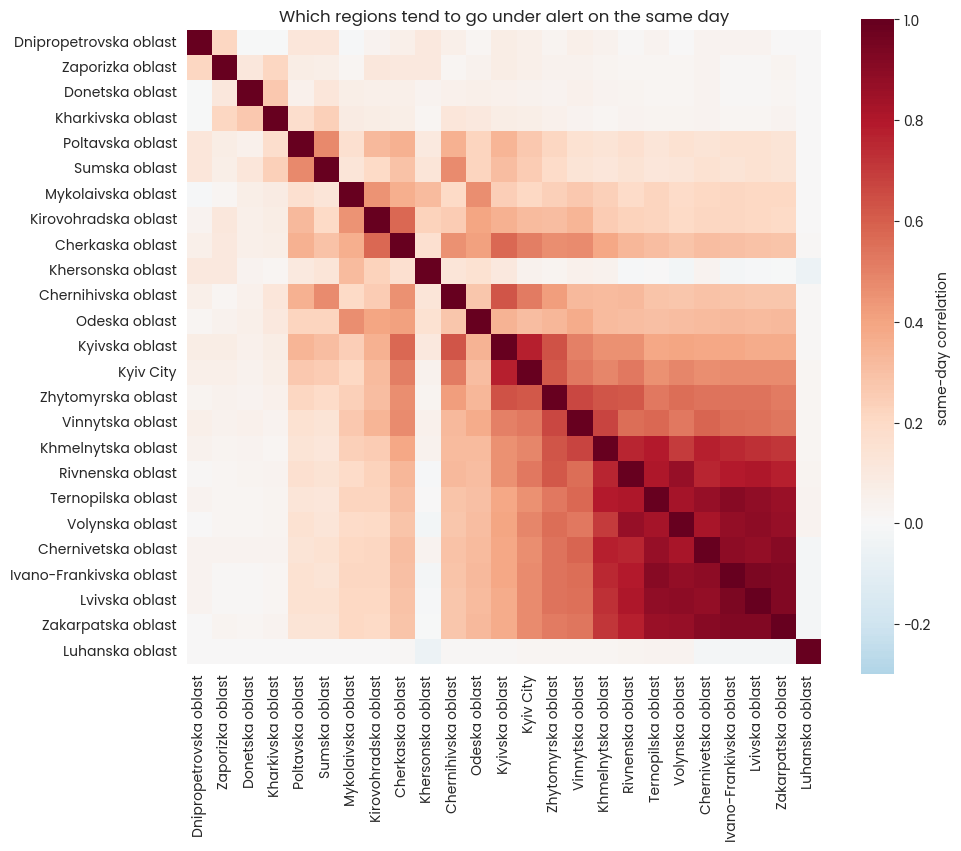

checked all 300 region pairs:
76% have their strongest link on the SAME day (no lag)


In [45]:
corr = presence[totals.index[::-1]].corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(corr, cmap='RdBu_r', vmin=-0.3, vmax=1, center=0, square=True,
            cbar_kws={'label': 'same-day correlation'}, ax=ax)
ax.set_title('Which regions tend to go under alert on the same day')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

import itertools
best_lags = []
for a, b in itertools.combinations(presence.columns, 2):
    sa, sb = presence[a] - presence[a].mean(), presence[b] - presence[b].mean()
    ccs = [np.corrcoef(sa.shift(lag).fillna(0), sb)[0,1] for lag in range(-5,6)]
    best_lags.append(range(-5,6)[int(np.argmax(ccs))])
best_lags = pd.Series(best_lags)
print(f'checked all {len(best_lags)} region pairs:')
print(f'{(best_lags==0).mean()*100:.0f}% have their strongest link on the SAME day (no lag)')

- **Dnipropetrovska, Zaporizka, Donetska and Kharkivska** — all on or near the front line — have been under alert on almost every day since 2022
- Western regions (Lviv, Ivano-Frankivsk, Chernivtsi, Zakarpattia) have been under alert roughly a **third as often**, consistent with their distance from the fighting
- **Khersonska oblast's data tells its own story:** almost silent while under Russian occupation (Mar-Aug 2022), a sharp rise during Ukraine's counteroffensive, and sustained high alert levels ever since liberation in November 2022
- **Luhanska oblast** shows almost no data — not because it's safe, but because most of it remains outside the area Ukraine's alert system covers
- Checked **every pair of regions**, not just one example: 76% have their strongest link on the *same day*, confirming this is mostly single nationwide waves hitting many regions at once, not a threat spreading gradually across the country
- The regions that *do* swing together strongly (bottom-right block on the grid above) are the ones that **aren't** on alert constantly — the busiest front-line regions are alerted so often there's little day-to-day variation left to correlate

## 4. Were there unusual spikes — and do they match real events?

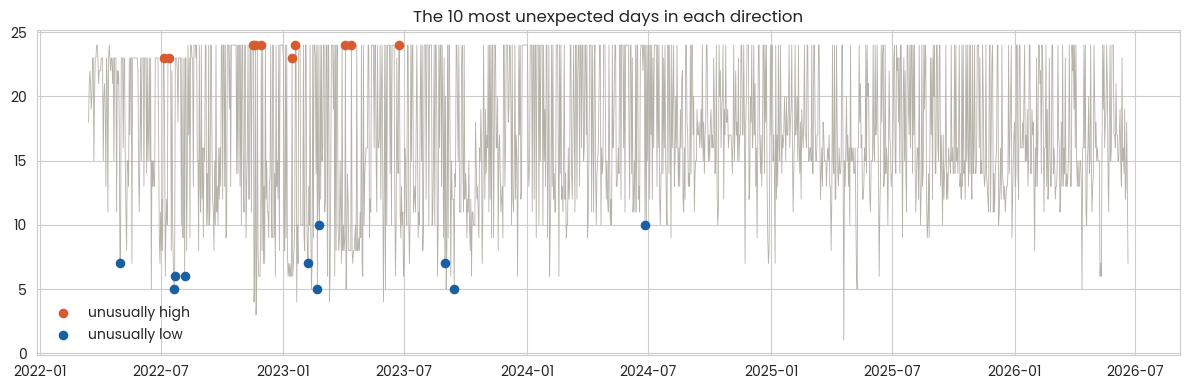

most unexpected spike days:
            regions
date               
2022-07-06       23
2022-11-20       24
2023-01-14       23
2023-01-19       24
2022-07-13       23
2023-06-24       24
2023-04-13       24
2022-11-17       24
2023-04-04       24
2022-11-29       24


In [46]:
resid = stl.resid
top_high = resid.sort_values(ascending=False).head(10)
top_low = resid.sort_values().head(10)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, lw=0.6, color='#B4B2A9')
ax.scatter(top_high.index, daily.loc[top_high.index], color='#D85A30', s=35, zorder=5, label='unusually high')
ax.scatter(top_low.index, daily.loc[top_low.index], color='#185FA5', s=35, zorder=5, label='unusually low')
ax.set_title('The 10 most unexpected days in each direction')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print('most unexpected spike days:')
print(daily.loc[top_high.index].rename('regions').to_frame())

Each of the 10 spike days was checked individually against real news/historical records — not assumed:

| Date | What actually happened |
|---|---|
| **17 Nov 2022** | Confirmed: large-scale Russian strike on infrastructure nationwide |
| **20 Nov 2022** | Within the documented Nov 2022 power-grid campaign (a 70-missile nationwide strike hit 23 Nov) |
| **29 Nov 2022** | Same campaign window |
| **14 Jan 2023** | Confirmed: Dnipro apartment-block strike (46+ killed), part of a nationwide missile barrage |
| **19 Jan 2023** | No single confirmed event found |
| **13 Apr 2023** | Matches the Good Friday Sloviansk strike (14 Apr, 15 killed) within a day |
| **4 Apr 2023** | No single confirmed event found |
| **24 Jun 2023** | Confirmed, but not a strike: this is the day of the **Wagner mutiny** in Russia — Ukraine's alert posture spiked amid the uncertainty, even without a major attack |
| **6 / 13 Jul 2022** | No single confirmed event found; both fall in an actively violent stretch of summer 2022 |

6 of 10 connect to a specific, confirmed real-world event. The rest aren't disproven — just not individually traceable to one headline.

- No comparably extreme spikes appear after 2023 — not because attacks became less frequent, but because **high alert activity is now the norm**, so even large barrages no longer stand out statistically

## 5. Can future alert activity be forecast?

In [47]:
recent = daily.loc[daily.index.max() - pd.Timedelta(days=364):]
train, test = recent.iloc[:-28], recent.iloc[-28:]
print(f'using the last 12 months ({len(recent)} days); testing on the final 28 days')

using the last 12 months (365 days); testing on the final 28 days


In [48]:
candidates = [(1,0,1,1,0,1), (1,0,2,1,0,1), (2,0,1,1,0,1), (1,0,1,0,0,1)]
results = []
for p, d, q, P, D, Q in candidates:
    with quiet():
        m = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,7),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    results.append({'settings': f'({p},{d},{q})({P},{D},{Q},7)', 'fit score (lower=better)': round(m.aic,1)})
print(pd.DataFrame(results).sort_values('fit score (lower=better)'))
best_order, best_seasonal = (1,0,2), (1,0,1,7)

           settings  fit score (lower=better)
1  (1,0,2)(1,0,1,7)                    1962.0
3  (1,0,1)(0,0,1,7)                    1965.4
0  (1,0,1)(1,0,1,7)                    1979.0
2  (2,0,1)(1,0,1,7)                    1980.1


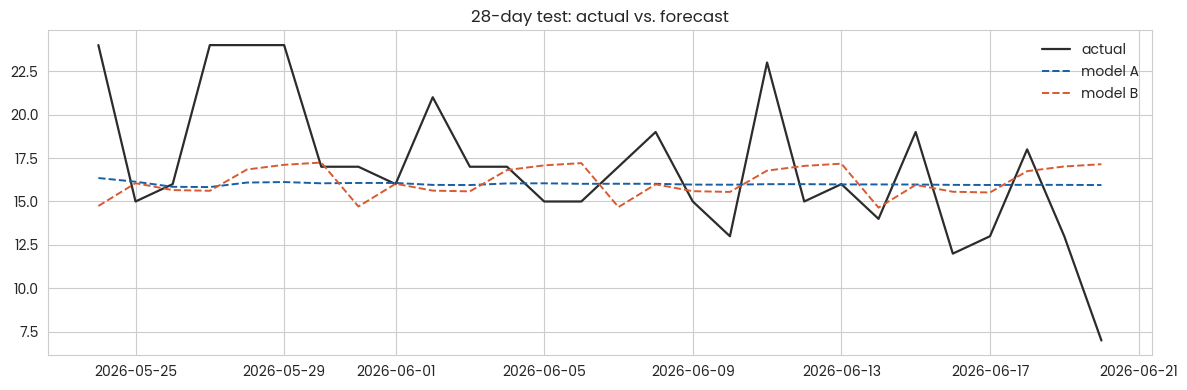

In [49]:
with quiet():
    sarima = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.get_forecast(steps=28).predicted_mean; sarima_fc.index = test.index

ptrain = train.reset_index().rename(columns={'date':'ds','oblasts_under_alert':'y'})
with quiet():
    prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
    prophet_model.fit(ptrain)
prophet_fc = (prophet_model.predict(prophet_model.make_future_dataframe(periods=28))
              .set_index('ds')['yhat'].loc[test.index])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index, test.values, color='#2C2C2A', lw=1.6, label='actual')
ax.plot(test.index, sarima_fc.values, color='#185FA5', lw=1.4, ls='--', label='model A')
ax.plot(test.index, prophet_fc.values, color='#D85A30', lw=1.4, ls='--', label='model B')
ax.set_title('28-day test: actual vs. forecast')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [50]:
HORIZON, N_FOLDS = 14, 5
initial = len(recent) - HORIZON * N_FOLDS
rows = []
for fold in range(N_FOLDS):
    cut = initial + fold * HORIZON
    tr, te = recent.iloc[:cut], recent.iloc[cut:cut + HORIZON]

    with quiet():
        sm = SARIMAX(tr, order=best_order, seasonal_order=best_seasonal,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sfc = sm.get_forecast(steps=HORIZON).predicted_mean; sfc.index = te.index

    ptr = tr.reset_index().rename(columns={'date':'ds','oblasts_under_alert':'y'})
    with quiet():
        pm = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False).fit(ptr)
    pfc = pm.predict(pm.make_future_dataframe(periods=HORIZON)).set_index('ds')['yhat'].loc[te.index]

    naive_fc = pd.Series(tr.iloc[-1], index=te.index)
    seasonal_naive_fc = pd.Series(np.tile(tr.iloc[-7:].values, HORIZON//7+1)[:HORIZON], index=te.index)

    for name, fc in [('model A', sfc), ('model B', pfc),
                      ('simple guess: same as last week', seasonal_naive_fc),
                      ('simple guess: same as yesterday', naive_fc)]:
        err = te - fc
        rows.append({'fold': fold+1, 'model': name, 'error (regions/day)': err.abs().mean()})

cv = pd.DataFrame(rows)
summary = cv.groupby('model')['error (regions/day)'].mean().sort_values()
print(summary.round(2))

model
model A                            3.57
model B                            3.71
simple guess: same as last week    4.80
simple guess: same as yesterday    6.14
Name: error (regions/day), dtype: float64


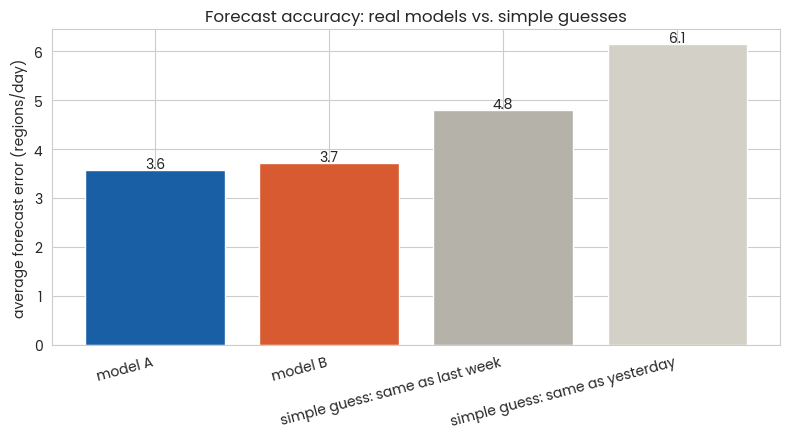

In [51]:
order = ['model A', 'model B', 'simple guess: same as last week', 'simple guess: same as yesterday']
colors = ['#185FA5', '#D85A30', '#B4B2A9', '#D3D1C7']
vals = [summary[m] for m in order]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(order, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.1f}', ha='center', fontsize=10)
ax.set_ylabel('average forecast error (regions/day)')
ax.set_title('Forecast accuracy: real models vs. simple guesses')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

- Two different forecasting approaches (model A, model B) were tested on the most recent year of data — both produced **almost identical, modest results**
- To check the models were actually worth building, they were compared against two trivial guesses: "tomorrow looks like today" and "this week looks like last week." The real models won clearly — **off by 3-4 regions/day** vs. **5-6 for the simple guesses** — so the modeling effort is genuinely adding value, not just complexity
- Even so, both real models **missed the largest swings entirely** — e.g. predicting ~16 regions on a day the real number jumped to 24, or fell to 7
- This isn't a flaw in the methods — it reflects what's being measured: **a decision made by an adversary, not a physical process with momentum**. These forecasts are best read as a "business as usual" baseline, not a real prediction of attacks

## Key insights

1. **Has alert activity changed since 2022?** Yes — highest right after the invasion, quietest and most erratic from late 2022 to mid-2023, then steadily elevated and more consistent since late 2023. An automatic check confirms 6 distinct phases, matching this story exactly.
2. **Is there a weekly pattern?** A modest one, clearer in quieter periods than in intense ones - peaks Thursday-Friday (17.8-18.0 regions/day), then drops over the weekend, bottoming out on Sunday (15.5). No winter/summer pattern, despite Russia's well-documented winter energy campaigns — they concentrate on fewer targets, not broader alerts.
3. **Which regions are hit hardest?** The front-line oblasts (Dnipropetrovska, Zaporizka, Donetska, Kharkivska) almost daily. Checked across all 300 region-pairs, not one example: 76% move together on the same day, confirming single nationwide waves as the dominant pattern. The data closely tracks real events, like Kherson's 2022 occupation and liberation.
4. **Were there unusual spikes?** Yes. Of the 10 most extreme days, 6 were individually traced to confirmed real events — including the 17 Nov 2022 infrastructure strike, the 14 Jan 2023 Dnipro strike, and even the 24 Jun 2023 Wagner mutiny in Russia.
5. **Can future activity be forecast?** Only roughly — but genuinely better than guessing: real models beat simple "repeat last week" guesses by a clear margin, yet still miss the big day-to-day swings, because those swings come from human decisions, not patterns in the data.

**Bottom line:** this data is a reliable mirror of the war as it has actually unfolded — but not a reliable predictor of what comes next.